## 1. Environment Setup

In [1]:
from google.colab import drive, userdata
from pathlib import Path
from zipfile import ZipFile
import pandas as pd

drive.mount('/content/drive')

DATA_ROOT = Path("/content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset")
PED1_PATH = DATA_ROOT / "UCSDped1"
PED2_PATH = DATA_ROOT / "UCSDped2"

ZIP_PATH = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/UCSD_Anomaly_Dataset.zip")
EXTRACT_PATH = Path("/content/UCSD_Anomaly_Dataset")

if not (PED1_PATH.exists() and PED2_PATH.exists()):
    with ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_PATH)

GH_TOKEN = userdata.get("GH_PAT")
REPO_DIR = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/repo")
REPO_URL = f"https://{GH_TOKEN}@github.com/Rishabh-G-Shetye/SurveillanceAnomalyDetection.git"

if not REPO_DIR.exists():
    !git clone {REPO_URL} "{REPO_DIR}"
%cd "{REPO_DIR}"

METADATA_PATH = REPO_DIR / "data" / "metadata.csv"
df = pd.read_csv(METADATA_PATH)

print("Ped1:", PED1_PATH.exists(), "| Ped2:", PED2_PATH.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
Ped1: True | Ped2: True


In [2]:
from PIL import Image

bad_files = []
for p in DATA_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in {".tif", ".tiff", ".jpg", ".jpeg", ".png", ".bmp"}:
        try:
            with Image.open(p) as img:
                img.load()
        except OSError as e:
            bad_files.append((p, str(e)))

print(f"Found {len(bad_files)} corrupted file(s):")
for p, err in bad_files:
    print(" ", p, "-", err)

Found 1 corrupted file(s):
  /content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset/UCSDped1/Test/Test017/142.tif - decoder error -2


## 2. Preprocessing Configuation
Ped1 (238x158) and Ped2(360x240)

In [3]:
import os
os.makedirs(REPO_DIR / "src" / "data", exist_ok=True)
(REPO_DIR / "src" / "__init__.py").touch()
(REPO_DIR / "src" / "data" / "__init__.py").touch()

In [4]:
%%writefile "{REPO_DIR}/src/data/ucsd_dataset.py"
"""
UCSD Anomaly Dataset -- windowed clip Dataset for PyTorch.

Loads short temporal windows ("clips") of consecutive frames from the
UCSD Ped1/Ped2 sequences, resizes/normalizes them, and returns clip-level
and frame-level anomaly labels for the Test split. Train sequences have no
ground truth (normal-only footage) and are returned unlabeled, matching the
project's semi-supervised / one-class setup. Windows containing an unreadable
(corrupted) frame are skipped rather than raising at training time.
"""

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

FRAME_SUFFIXES = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}
DATASET_DIR_MAP = {"Ped1": "UCSDped1", "Ped2": "UCSDped2"}


@dataclass
class PreprocessConfig:
    """Per-dataset preprocessing configuration."""
    target_size: tuple[int, int] = (128, 128)
    window_length: int = 8
    stride: int = 4
    mean: float = 0.5
    std: float = 0.5


def build_transform(config: PreprocessConfig) -> transforms.Compose:
    """Resize + tensor + normalize transform for a single grayscale frame."""
    return transforms.Compose([
        transforms.Resize(config.target_size),
        transforms.ToTensor(),# (1, H, W), values in [0, 1]
        transforms.Normalize(mean=[config.mean], std=[config.std]),
    ])


def _is_readable(path: Path) -> bool: #corruption check and removal
    """Return False if an image file is missing, truncated, or undecodable."""
    try:
        with Image.open(path) as img:
            img.load()
        return True
    except (OSError, IOError):
        return False


class UCSDClipDataset(Dataset):
    """
    Windowed clip dataset for one UCSD sub-dataset (Ped1 or Ped2) and split.

    Each item is a clip of `config.window_length` consecutive frames from a
    single sequence (windows never cross sequence boundaries), shaped
    (T, 1, H, W). Any window containing a corrupted frame is excluded at
    construction time, so __getitem__ never has to handle decode errors.

    Test split: `clip_label` = 1 if any frame in the window is anomalous;
    `frame_labels` gives the per-frame binary label, shape (T,).
    Train split (no ground truth): both are all-zero placeholders.
    """

    def __init__(
        self,
        metadata_df: pd.DataFrame,
        data_root: Path,
        dataset_name: str,
        split: str,
        config: PreprocessConfig,
    ):
        self.data_root = Path(data_root)
        self.config = config
        self.transform = build_transform(config)

        seq_names = metadata_df.loc[
            (metadata_df["dataset"] == dataset_name) & (metadata_df["split"] == split),
            "sequence",
        ].tolist()

        split_path = self.data_root / DATASET_DIR_MAP[dataset_name] / split

        self.windows = []       # list of (frame_paths, gt_paths_or_None)
        self.skipped_count = 0  # windows dropped due to a corrupted frame

        for seq_name in seq_names:
            seq_dir = split_path / seq_name
            frame_paths = sorted(
                p for p in seq_dir.iterdir()
                if p.is_file() and p.suffix.lower() in FRAME_SUFFIXES
            )

            # Check each frame in this sequence once, not once per window.
            readable = {p: _is_readable(p) for p in frame_paths}

            gt_dir = split_path / f"{seq_name}_gt"
            gt_paths = None
            if gt_dir.exists():
                gt_paths = sorted(p for p in gt_dir.iterdir() if p.suffix.lower() == ".bmp")

            n = len(frame_paths)
            for start in range(0, n - config.window_length + 1, config.stride):
                fp_window = frame_paths[start:start + config.window_length]

                if not all(readable[p] for p in fp_window):
                    self.skipped_count += 1
                    continue

                gt_window = gt_paths[start:start + config.window_length] if gt_paths else None
                self.windows.append((fp_window, gt_window))

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int):
        frame_paths, gt_paths = self.windows[idx]

        frames = [self.transform(Image.open(p).convert("L")) for p in frame_paths]
        clip = torch.stack(frames, dim=0)  # (T, 1, H, W)

        if gt_paths is not None:
            frame_labels = np.array(
                [1 if (np.array(Image.open(p)) > 0).any() else 0 for p in gt_paths],
                dtype=np.int64,
            )
        else:
            frame_labels = np.zeros(len(frame_paths), dtype=np.int64)

        clip_label = int(frame_labels.any())

        return {
            "clip": clip,
            "clip_label": clip_label,
            "frame_labels": torch.from_numpy(frame_labels),
        }

Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/data/ucsd_dataset.py


In [5]:
from PIL import Image

bad_files = []
for p in DATA_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in {".tif", ".tiff", ".jpg", ".jpeg", ".png", ".bmp"}:
        try:
            with Image.open(p) as img:
                img.load()
        except OSError as e:
            bad_files.append((p, str(e)))

print(f"Found {len(bad_files)} corrupted file(s):")
for p, err in bad_files:
    print(" ", p, "-", err)

Found 1 corrupted file(s):
  /content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset/UCSDped1/Test/Test017/142.tif - decoder error -2


## 3. Load Module and Initialize the Configs

In [6]:
import sys
sys.path.insert(0, str(REPO_DIR / "src"))

from data.ucsd_dataset import PreprocessConfig, UCSDClipDataset
ped1_config = PreprocessConfig(target_size=(128, 128), window_length=8, stride=4)
ped2_config = PreprocessConfig(target_size=(128, 128), window_length=8, stride=4)

In [7]:
train_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Train", ped1_config)
test_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Test", ped1_config)

print("Skipped (corrupted) train windows:", train_ds.skipped_count)
print("Skipped (corrupted) test windows:", test_ds.skipped_count)

Skipped (corrupted) train windows: 0
Skipped (corrupted) test windows: 2


##4. Datasets and DataLoaders

In [8]:
train_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Train", ped1_config)
test_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Test", ped1_config)

sample = train_ds[0]
print("Train clips:", len(train_ds), "| Test clips:", len(test_ds))
print("Clip shape:", sample["clip"].shape)# (T, 1, H, W)

test_labels = [test_ds[i]["clip_label"] for i in range(len(test_ds))]
print(f"Test clip label balance -- anomalous: {sum(test_labels)} / {len(test_labels)} "
      f"({100 * sum(test_labels) / len(test_labels):.1f}%)")

Train clips: 1666 | Test clips: 1762
Clip shape: torch.Size([8, 1, 128, 128])
Test clip label balance -- anomalous: 321 / 1762 (18.2%)


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
batch = next(iter(train_loader))

print("Batch clip shape:", batch["clip"].shape)# (B, T, 1, H, W)
print("Batch clip_label shape:", batch["clip_label"].shape)
print("Batch frame_labels shape:", batch["frame_labels"].shape)

Batch clip shape: torch.Size([8, 8, 1, 128, 128])
Batch clip_label shape: torch.Size([8])
Batch frame_labels shape: torch.Size([8, 8])


##5. Visual sanity check

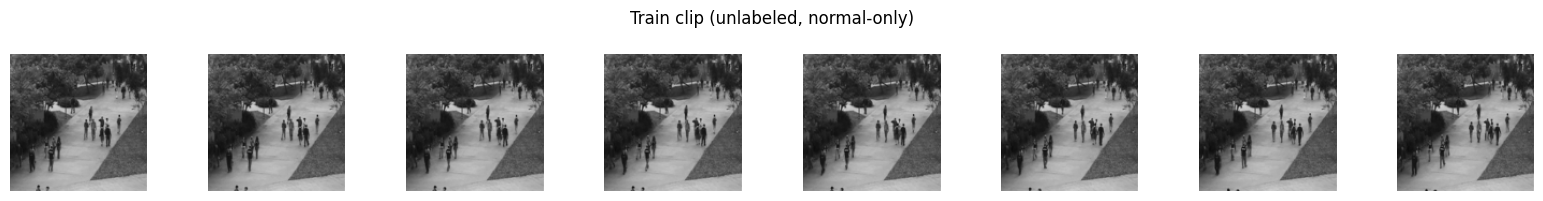

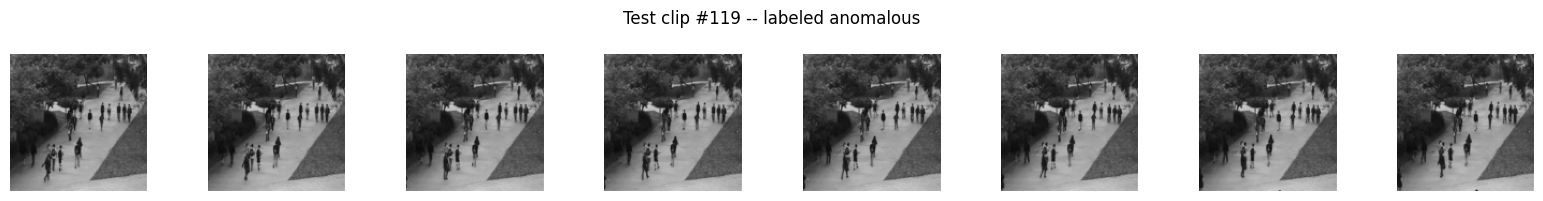

In [10]:
import matplotlib.pyplot as plt

def show_clip(clip, title, mean=0.5, std=0.5):
    """Display all T frames of a (T, 1, H, W) clip as a horizontal strip.
    Un-normalizes using the same mean/std the transform applied."""
    T = clip.shape[0]
    fig, axes = plt.subplots(1, T, figsize=(2 * T, 2))
    for t in range(T):
        img = (clip[t, 0].numpy() * std) + mean
        axes[t].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[t].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_clip(train_ds[0]["clip"], "Train clip (unlabeled, normal-only)",
          ped1_config.mean, ped1_config.std)

anomalous_idx = next(i for i in range(len(test_ds)) if test_ds[i]["clip_label"] == 1)
show_clip(test_ds[anomalous_idx]["clip"], f"Test clip #{anomalous_idx} -- labeled anomalous",
          ped1_config.mean, ped1_config.std)

In [ ]:
%cd "{REPO_DIR}"
!git add notebooks/03_ucsd_preprocessing_pipeline.ipynb
!git commit -m "Implement UCSD dataset preprocessing and data loading pipeline"
!git push

/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
